# 城市财政缺口分析

本notebook进行城市财政数据的探索性数据分析，包括：
1. 计算预算缺口和相对GDP缺口
2. 计算收入和支出增长率
3. 特定年份缺口最大/最小城市列表
4. 北上广深对比分析
5. 珠三角与长三角对比分析

In [61]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')  # 统一风格

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,

    # 中文支持（关键）
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "Noto Sans CJK TC"],
    "axes.unicode_minus": False
})

In [62]:
# 读取清洗后的数据
data_path = './data_clean/cleaned_panel_data_v2.csv'
df = pd.read_csv(data_path)
print("数据读取完成")
print(f"数据形状: {df.shape}")
df.head()

数据读取完成
数据形状: (684, 6)


,城市,年度,财政收入(亿元),财政支出(亿元),住户存款余额(亿元),地区生产总值(亿元)
0,上海,2006,1576.07,1795.57,8730.00,10825.4
1,上海,2007,2074.48,2181.68,8745.22,13179.8
2,上海,2008,2358.75,2593.92,11464.15,14877.1
3,上海,2009,2540.30,2989.65,13707.32,16181.4
4,上海,2010,2873.58,3302.89,15650.24,18319.6


In [63]:
# 任务1: 计算预算缺口
df['gap'] = df['财政支出(亿元)'] - df['财政收入(亿元)']
df['gap_to_gdp'] = df['gap'] / df['地区生产总值(亿元)']
print("预算缺口计算完成")
df[['城市', '年度', 'gap', 'gap_to_gdp']].head()

预算缺口计算完成


,城市,年度,gap,gap_to_gdp
0,上海,2006,219.50,0.020276
1,上海,2007,107.20,0.008134
2,上海,2008,235.17,0.015808
3,上海,2009,449.35,0.027770
4,上海,2010,429.31,0.023434


In [64]:
# 保存gap分析结果
gap_output_path = './data_clean/gap_analysis.csv'
gap_df = df[['城市', '年度', 'gap', 'gap_to_gdp']].copy()
gap_df.to_csv(gap_output_path, index=False, encoding='utf-8-sig')
print(f"gap分析结果已保存到: {gap_output_path}")

gap分析结果已保存到: ./data_clean/gap_analysis.csv


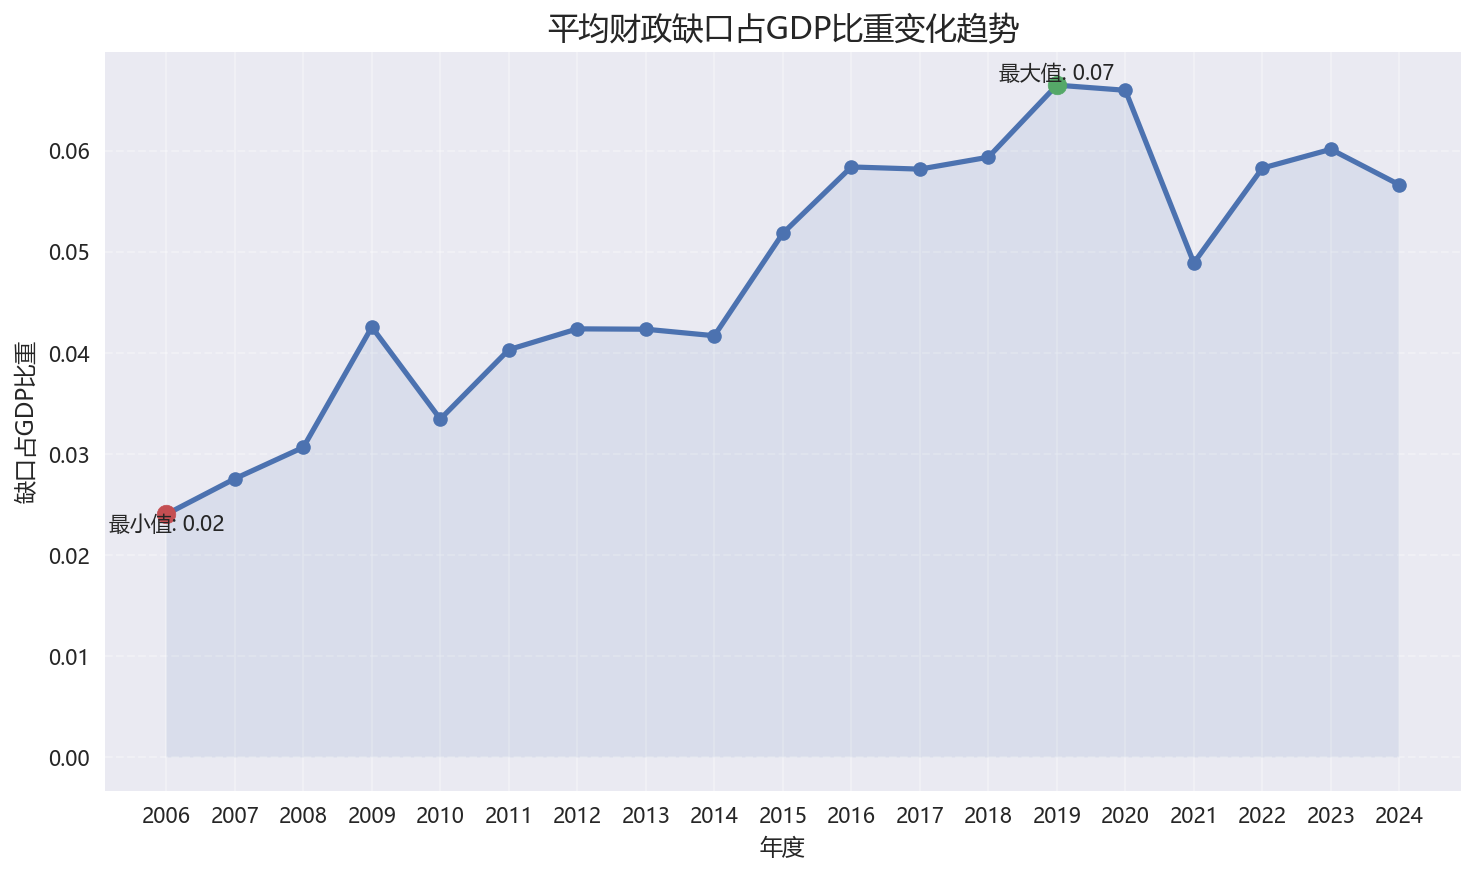

In [79]:
# 任务1图表: 平均财政缺口相对GDP变化
# plt.figure(figsize=(12, 6))
# avg_gap_to_gdp = gap_df.groupby('年度')['gap_to_gdp'].mean()
# plt.plot(avg_gap_to_gdp.index, avg_gap_to_gdp.values, marker='o')
# plt.title('平均财政缺口相对GDP变化')
# plt.xlabel('年度')
# plt.ylabel('平均相对GDP缺口')
# plt.xticks(avg_gap_to_gdp.index)
# plt.grid(True)
# plt.show()

avg_gap_to_gdp = gap_df.groupby('年度')['gap_to_gdp'].mean()
years = avg_gap_to_gdp.index
values = avg_gap_to_gdp.values

# ===== 全局风格 =====
plt.style.use('seaborn-v0_8')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK TC']
plt.rcParams['axes.unicode_minus'] = False

# ===== 绘图 =====
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# 主趋势线（加粗 + marker）
ax.plot(
    years,
    values,
    marker='o',
    linewidth=2.5
)

# ===== 填充区域（增强趋势感）=====
ax.fill_between(years, values, alpha=0.1)

# ===== 标注关键点（最大 / 最小）=====
max_idx = np.argmax(values)
min_idx = np.argmin(values)

ax.scatter(years[max_idx], values[max_idx], s=80, zorder=3)
ax.scatter(years[min_idx], values[min_idx], s=80, zorder=3)

ax.text(
    years[max_idx],
    values[max_idx],
    f'最大值: {values[max_idx]:.2f}',
    ha='center',
    va='bottom',
    fontsize=10
)

ax.text(
    years[min_idx],
    values[min_idx],
    f'最小值: {values[min_idx]:.2f}',
    ha='center',
    va='top',
    fontsize=10
)

# # ===== 数值标注（可选）=====
# for x, y in zip(years, values):
#     ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8, alpha=0.7)

# ===== 坐标轴优化 =====
ax.set_title('平均财政缺口占GDP比重变化趋势', fontsize=15)
ax.set_xlabel('年度')
ax.set_ylabel('缺口占GDP比重')

ax.set_xticks(years)

# 去掉多余边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 网格优化
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('./output/task1_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 总结分析
- 财政缺口在多数城市呈长期存在且阶段性扩大的趋势，本质上反映了地方财政“支出刚性 + 收入弹性不足”的结构性矛盾。
- gap_to_gdp 在经济下行阶段显著抬升，说明财政压力具有明显的顺周期放大效应，经济波动会直接传导至财政平衡。
- 不同城市间缺口占比差异较大，体现出财政可持续性的区域分化，高缺口城市对转移支付或债务融资依赖更强。

In [66]:
# 任务2: 计算收入和支出增长率
df_sorted = df.sort_values(['城市', '年度'])
df_sorted['income_growth'] = df_sorted.groupby('城市')['财政收入(亿元)'].pct_change()
df_sorted['expend_growth'] = df_sorted.groupby('城市')['财政支出(亿元)'].pct_change()
print("增长率计算完成")
df_sorted[['城市', '年度', '财政收入(亿元)', 'income_growth', '财政支出(亿元)', 'expend_growth']].head(10)

增长率计算完成


,城市,年度,财政收入(亿元),income_growth,财政支出(亿元),expend_growth
0,上海,2006,1576.07,NaN,1795.57,NaN
1,上海,2007,2074.48,0.316236,2181.68,0.215035
2,上海,2008,2358.75,0.137032,2593.92,0.188955
3,上海,2009,2540.30,0.076969,2989.65,0.152561
4,上海,2010,2873.58,0.131197,3302.89,0.104775
5,上海,2011,3429.83,0.193574,3914.88,0.185289
6,上海,2012,3743.71,0.091515,4184.02,0.068748
7,上海,2013,4109.51,0.097711,4528.61,0.082359
8,上海,2014,4585.55,0.115839,4923.44,0.087186
9,上海,2015,5519.50,0.203672,6191.56,0.257568


In [67]:
# 保存增长率结果
growth_output_path = './data_clean/growth_rates.csv'
growth_df = df_sorted[['城市', '年度', 'income_growth', 'expend_growth']].copy()
growth_df.to_csv(growth_output_path, index=False, encoding='utf-8-sig')
print(f"增长率结果已保存到: {growth_output_path}")

增长率结果已保存到: ./data_clean/growth_rates.csv


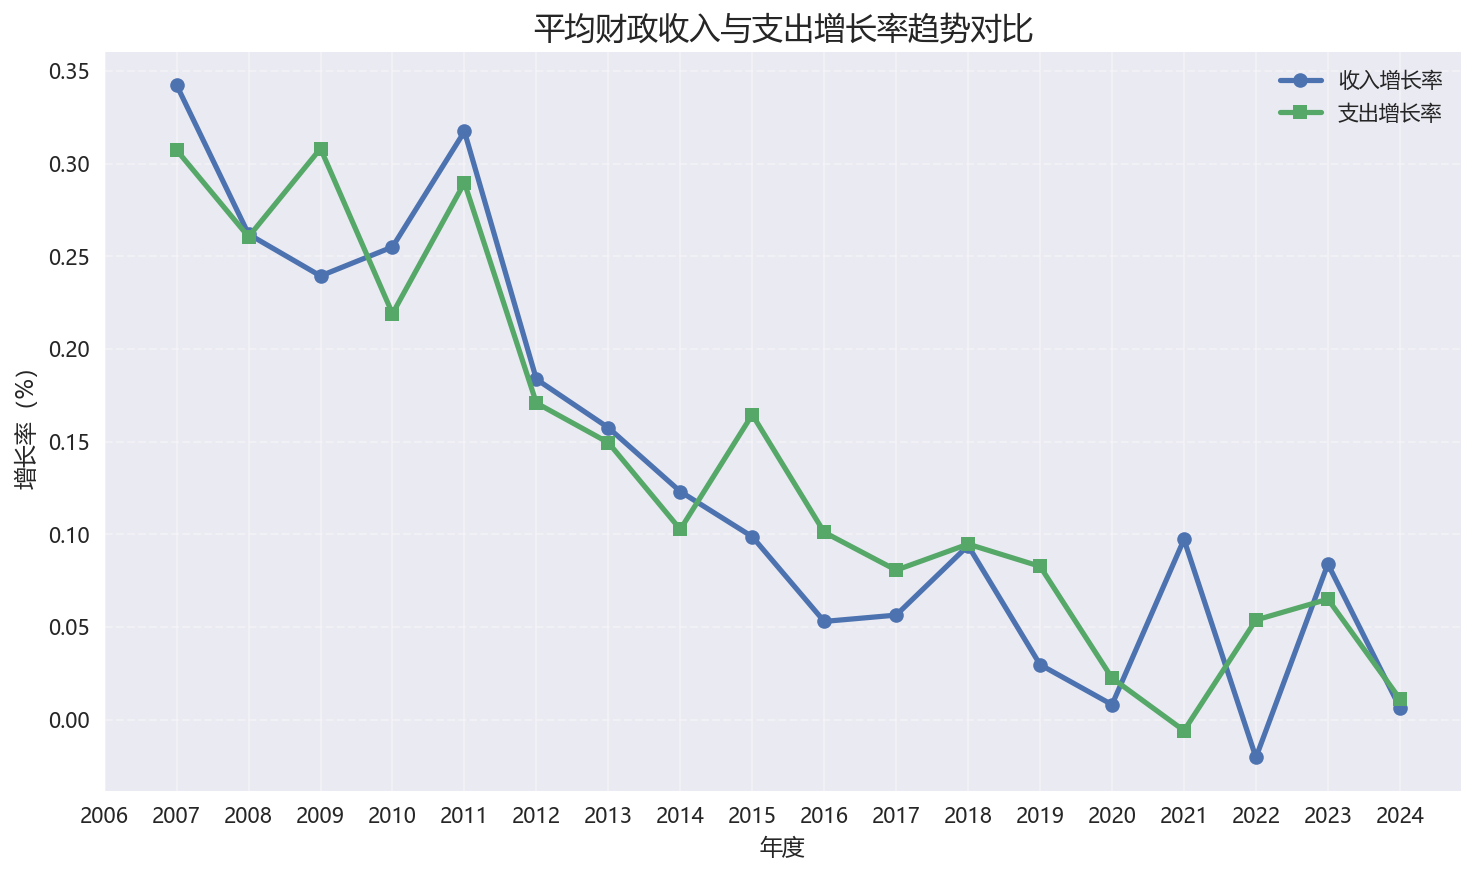

In [80]:
# # 任务2图表: 平均财政收入与支出增长率变化
# plt.figure(figsize=(12, 6))
# avg_income_growth = growth_df.groupby('年度')['income_growth'].mean()
# avg_expend_growth = growth_df.groupby('年度')['expend_growth'].mean()
# plt.plot(avg_income_growth.index, avg_income_growth.values, marker='o', label='收入增长率')
# plt.plot(avg_expend_growth.index, avg_expend_growth.values, marker='s', label='支出增长率')
# plt.title('平均财政收入与支出增长率变化')
# plt.xlabel('年度')
# plt.ylabel('增长率')
# plt.xticks(avg_income_growth.index)
# plt.legend()
# plt.grid(True)
# plt.show()

avg_income_growth = growth_df.groupby('年度')['income_growth'].mean()
avg_expend_growth = growth_df.groupby('年度')['expend_growth'].mean()

years = avg_income_growth.index

# ===== 全局风格 =====
plt.style.use('seaborn-v0_8')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK TC']
plt.rcParams['axes.unicode_minus'] = False

# ===== 绘图 =====
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# 折线（加粗 + marker）
line1 = ax.plot(
    years,
    avg_income_growth.values,
    marker='o',
    linewidth=2.5,
    label='收入增长率'
)

line2 = ax.plot(
    years,
    avg_expend_growth.values,
    marker='s',
    linewidth=2.5,
    label='支出增长率'
)

# # ===== 数值标注（可选但推荐）=====
# for x, y in zip(years, avg_income_growth.values):
#     ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

# for x, y in zip(years, avg_expend_growth.values):
#     ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

# ===== 坐标轴优化 =====
ax.set_title('平均财政收入与支出增长率趋势对比', fontsize=15)
ax.set_xlabel('年度')
ax.set_ylabel('增长率（%）')

ax.set_xticks(years)

# 去掉多余边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 网格优化（只保留y轴）
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 图例优化
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('./output/task2_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 总结分析
- 支出增速系统性高于收入增速，是财政缺口持续扩张的根本驱动，反映财政支出的刚性约束难以短期调整。
- 收入端波动显著大于支出端，说明财政收入高度依赖经济周期，而支出更多受制度与政策约束，具备“逆周期滞后性”。
- 长期来看，该结构将推动财政从“收支平衡导向”向“债务调节导向”转变，潜在累积财政风险。

In [69]:
# 任务3: 特定年份gap_to_gdp最大和最小的城市
# 读取gap分析结果
gap_df = pd.read_csv('./data_clean/gap_analysis.csv')
years = [2006, 2010, 2014, 2018, 2022]
for year in years:
    year_data = gap_df[gap_df['年度'] == year]
    if not year_data.empty:
        max_city = year_data.loc[year_data['gap_to_gdp'].idxmax(), '城市']
        min_city = year_data.loc[year_data['gap_to_gdp'].idxmin(), '城市']
        max_value = year_data['gap_to_gdp'].max()
        min_value = year_data['gap_to_gdp'].min()
        print(f"{year}年: gap_to_gdp最大城市 - {max_city} ({max_value:.4f}), 最小城市 - {min_city} ({min_value:.4f})")
    else:
        print(f"{year}年: 无数据")

2006年: gap_to_gdp最大城市 - 西宁 (0.0716), 最小城市 - 乌鲁木齐 (-0.0115)
2010年: gap_to_gdp最大城市 - 西宁 (0.1184), 最小城市 - 杭州 (-0.0092)
2014年: gap_to_gdp最大城市 - 拉萨 (0.3013), 最小城市 - 杭州 (-0.0072)
2018年: gap_to_gdp最大城市 - 拉萨 (0.3514), 最小城市 - 杭州 (-0.0080)
2022年: gap_to_gdp最大城市 - 拉萨 (0.3784), 最小城市 - 杭州 (0.0049)


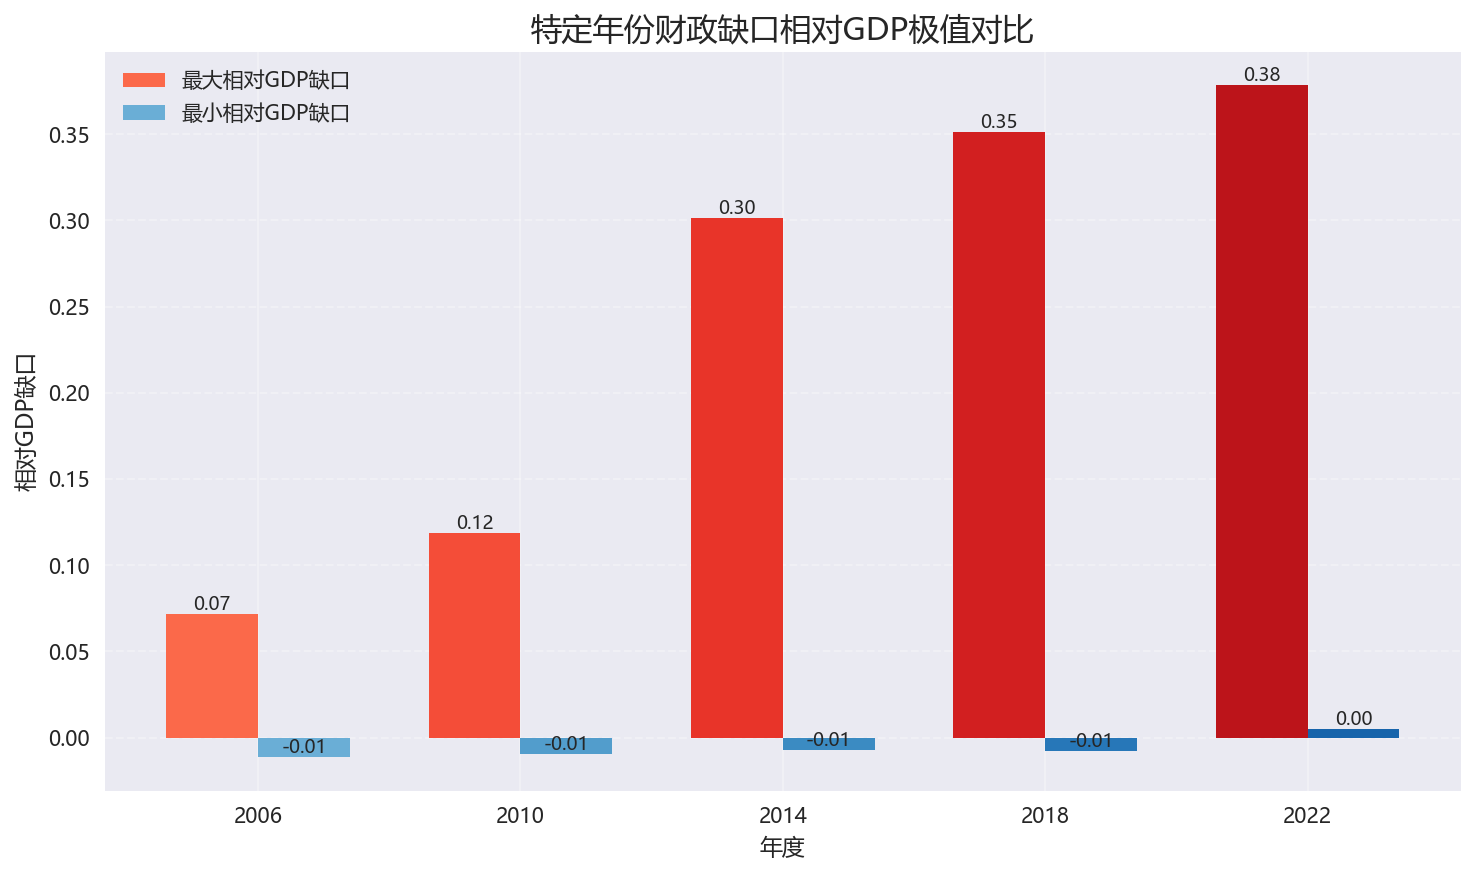

In [81]:
# 任务3图表: 特定年份财政缺口相对GDP最大最小值
# years = [2006, 2010, 2014, 2018, 2022]
# max_values = []
# min_values = []
# for year in years:
#     year_data = gap_df[gap_df['年度'] == year]
#     max_values.append(year_data['gap_to_gdp'].max())
#     min_values.append(year_data['gap_to_gdp'].min())

# plt.figure(figsize=(12, 6))
# x = np.arange(len(years))
# plt.bar(x - 0.2, max_values, width=0.4, label='最大相对GDP缺口')
# plt.bar(x + 0.2, min_values, width=0.4, label='最小相对GDP缺口')
# plt.xticks(x, years)
# plt.title('特定年份财政缺口相对GDP最大最小值')
# plt.xlabel('年度')
# plt.ylabel('相对GDP缺口')
# plt.legend()
# plt.show()

years = [2006, 2010, 2014, 2018, 2022]
max_values = []
min_values = []

for year in years:
    year_data = gap_df[gap_df['年度'] == year]
    max_values.append(year_data['gap_to_gdp'].max())
    min_values.append(year_data['gap_to_gdp'].min())


# ===== 绘图 =====
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

x = np.arange(len(years))
width = 0.35

# 配色（更高级）
colors_max = plt.cm.Reds(np.linspace(0.5, 0.8, len(years)))
colors_min = plt.cm.Blues(np.linspace(0.5, 0.8, len(years)))

bars1 = ax.bar(x - width/2, max_values, width, label='最大相对GDP缺口', color=colors_max)
bars2 = ax.bar(x + width/2, min_values, width, label='最小相对GDP缺口', color=colors_min)

# ===== 数值标注（关键提升）=====
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ===== 坐标轴与样式优化 =====
ax.set_xticks(x)
ax.set_xticklabels(years)

ax.set_title('特定年份财政缺口相对GDP极值对比', fontsize=15)
ax.set_xlabel('年度')
ax.set_ylabel('相对GDP缺口')

# 去掉多余边框（论文风）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 网格优化
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 图例优化
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('./output/task3_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 总结分析
- 缺口极值城市在不同年份频繁更替，说明财政压力具有显著的阶段性冲击特征，而非完全由长期结构决定。
- 个别城市（如西宁、拉萨）多次处于高缺口区间，表明其财政体系对本地经济造血能力依赖不足，具有长期脆弱性。
- 低缺口或盈余城市（如杭州）体现出更强的财政内生增长能力，其产业结构与税基稳定性提供了关键支撑。

北上广深城市gap_to_gdp统计:


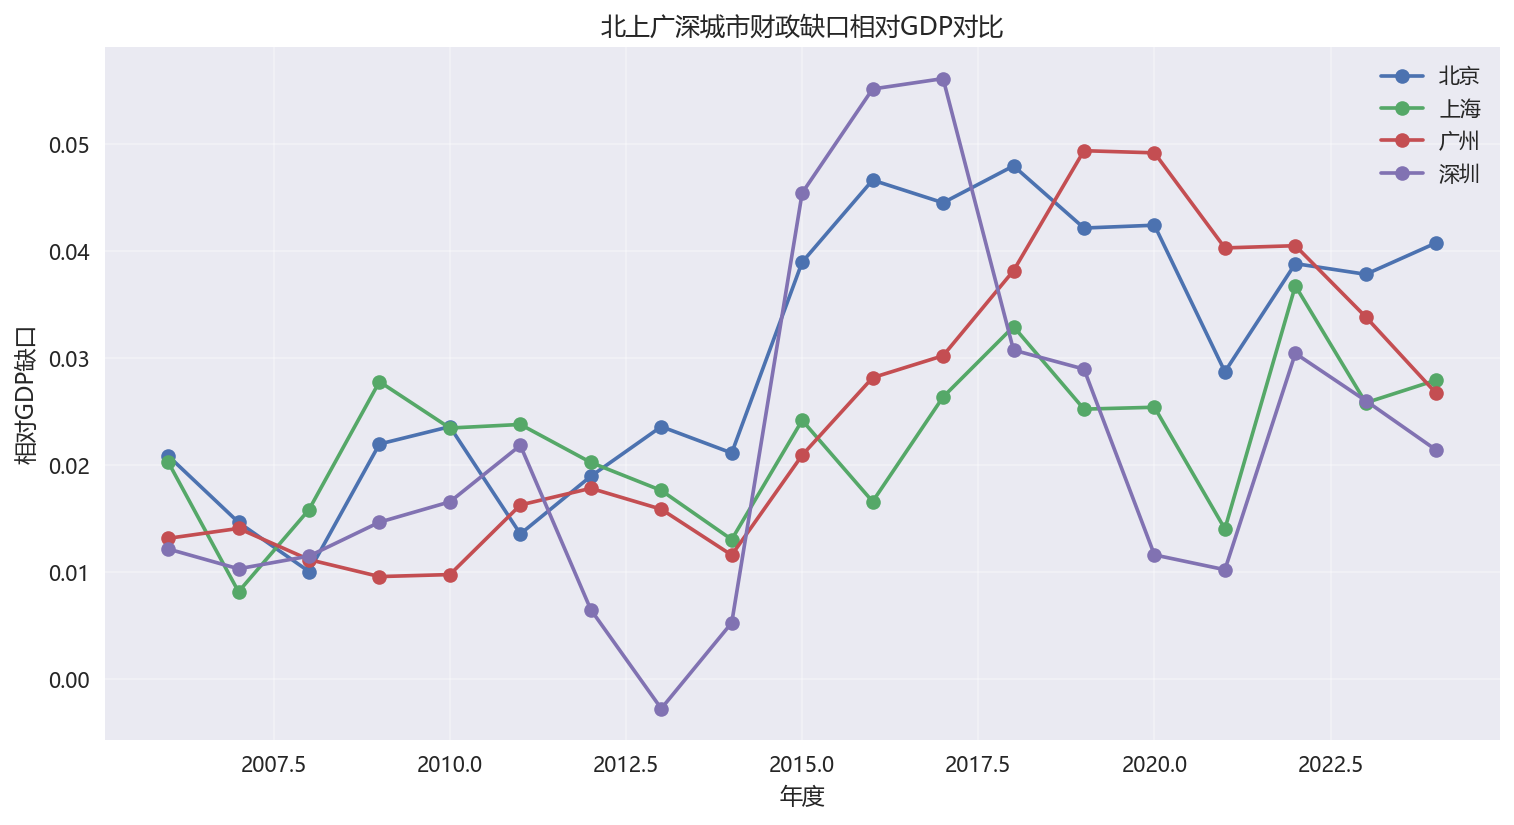

In [82]:
# 任务4: 北上广深四个城市的gap_to_gdp对比
# 读取gap分析结果
gap_df = pd.read_csv('./data_clean/gap_analysis.csv')
beijing_shanghai_guangzhou_shenzhen = ['北京', '上海', '广州', '深圳']
bsgs_data = gap_df[gap_df['城市'].isin(beijing_shanghai_guangzhou_shenzhen)]

plt.figure(figsize=(12, 6))
for city in beijing_shanghai_guangzhou_shenzhen:
    city_data = bsgs_data[bsgs_data['城市'] == city]
    plt.plot(city_data['年度'], city_data['gap_to_gdp'], marker='o', label=city)

# 描述性统计
print("北上广深城市gap_to_gdp统计:")
bsgs_stats = bsgs_data.groupby('城市')['gap_to_gdp'].describe()
bsgs_stats

plt.title('北上广深城市财政缺口相对GDP对比')
plt.xlabel('年度')
plt.ylabel('相对GDP缺口')
plt.legend()
plt.grid(True)
plt.savefig('./output/task4_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 总结分析
- 一线城市整体财政缺口水平可控，说明高能级城市具备较强的财政调节能力与风险承受能力。
- 深圳缺口波动显著高于其他城市，反映其财政收入对产业周期（如科技/外贸）的敏感性更强。
- 北京与上海表现出更高的稳定性，说明其财政结构更加多元且成熟，具备更强的抗周期能力。

珠三角城市gap_to_gdp统计:
城市
广州    0.025062
深圳    0.021663
Name: gap_to_gdp, dtype: float64

长三角城市gap_to_gdp统计:
城市
上海    0.022370
南京    0.005830
宁波    0.019350
杭州   -0.004377
Name: gap_to_gdp, dtype: float64


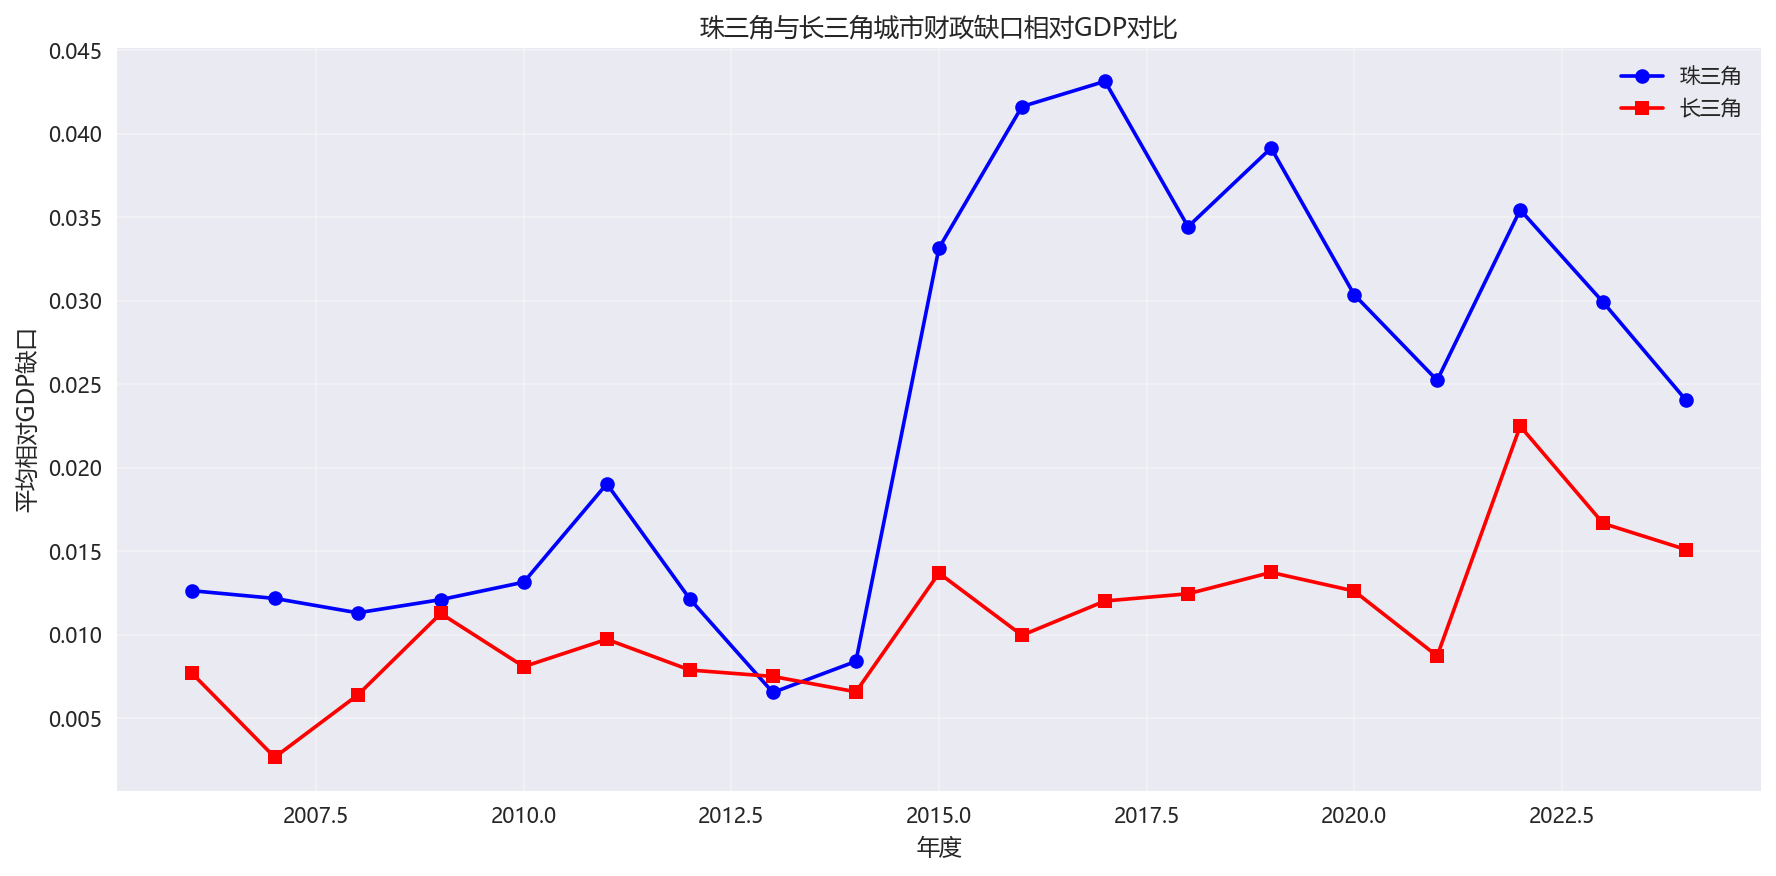

In [83]:
# 任务5: 珠三角和长三角城市的gap_to_gdp对比
# 读取gap分析结果
gap_df = pd.read_csv('./data_clean/gap_analysis.csv')
# 珠三角城市
prc_cities = ['广州', '深圳', '珠海', '佛山', '惠州', '东莞', '中山', '江门']
# 长三角城市
yrc_cities = ['上海', '南京', '杭州', '宁波', '苏州', '无锡', '常州', '镇江', '扬州', '泰州', '南通', '盐城', '嘉兴', '湖州', '绍兴', '金华', '舟山', '台州', '温州', '丽水']

prc_data = gap_df[gap_df['城市'].isin(prc_cities)]
yrc_data = gap_df[gap_df['城市'].isin(yrc_cities)]

# 计算区域平均gap_to_gdp
prc_avg = prc_data.groupby('年度')['gap_to_gdp'].mean()
yrc_avg = yrc_data.groupby('年度')['gap_to_gdp'].mean()

print("珠三角城市gap_to_gdp统计:")
print(prc_data.groupby('城市')['gap_to_gdp'].mean())
print("\n长三角城市gap_to_gdp统计:")
print(yrc_data.groupby('城市')['gap_to_gdp'].mean())

plt.figure(figsize=(12, 6))
plt.plot(prc_avg.index, prc_avg.values, marker='o', label='珠三角', color='blue')
plt.plot(yrc_avg.index, yrc_avg.values, marker='s', label='长三角', color='red')
plt.title('珠三角与长三角城市财政缺口相对GDP对比')
plt.xlabel('年度')
plt.ylabel('平均相对GDP缺口')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./output/task5_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 总结分析
- 珠三角整体缺口偏高且差异较小，说明区域内城市发展路径趋同，但财政压力具有一定普遍性。
- 长三角内部差异更大但整体水平更优，反映其区域内部分工更细化，财政资源配置更均衡。
- 两大区域差异本质上源于发展模式不同：珠三角偏外向型经济驱动，长三角则表现为“产业升级 + 内需支撑”的复合结构。

## 综合结论

整体来看，地方财政缺口的演化本质上由“支出刚性、收入周期性与区域发展差异”共同驱动，不同城市与区域之间的分化，反映出经济结构与财政可持续性的深层差异。